## Setup

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import random 
import copy

# Load feature arrays
X_list = []
for i in range(1, 10):
    X = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    X = X[:, None, :, :]      # Add channel dimension
    X_list.append(X)

# Combine into one dataset
X = np.concatenate(X_list, axis=0)

print("X shape:", X.shape)


# Load label arrays
y_list = []
for i in range(1, 10):
    y = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")
    y_list.append(y)

# Combine labels
y = np.concatenate(y_list, axis=0)

print("y shape:", y.shape)


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [2]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [4]:
batch_size = 32
num_epochs = 60
k = 9

skf = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

X_cv = X
y_cv = y

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

## Both



================ SCALE 0.5 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8659979423868314), 'fmeasure': 0.6157217131403224}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6597222222222222, 'auc': np.float64(0.8801601080246915), 'fmeasure': 0.6572777849644694}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8640608924897121), 'fmeasure': 0.6248857485797784}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6736111111111112, 'auc': np.float64(0.875683191872428), 'fmeasure': 0.6724134556739045}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8709530928497943), 'fmeasure': 0.6227636772498409}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8591177983539094), 'fmeasure': 0.6326760857485046}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8734527713477366), 'fmeasure': 0.6434507456610976}

Fold 8/9

Fold 

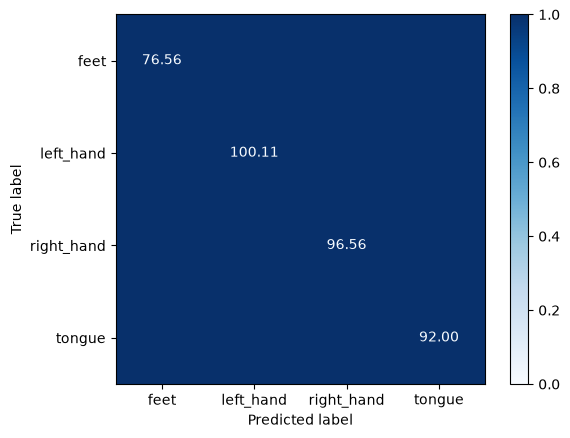



================ SCALE 1.5 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6423611111111112, 'auc': np.float64(0.8679591049382717), 'fmeasure': 0.6393264412894945}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8830978330761315), 'fmeasure': 0.6563761927158377}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8690602494855968), 'fmeasure': 0.6429534476962184}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8716603973765432), 'fmeasure': 0.6375983249926912}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8768044302983539), 'fmeasure': 0.6312438193527222}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8743931648662552), 'fmeasure': 0.6300539577597322}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8612839184670781), 'fmeasure': 0.6297403312046721}

Fold 8/9

Fo

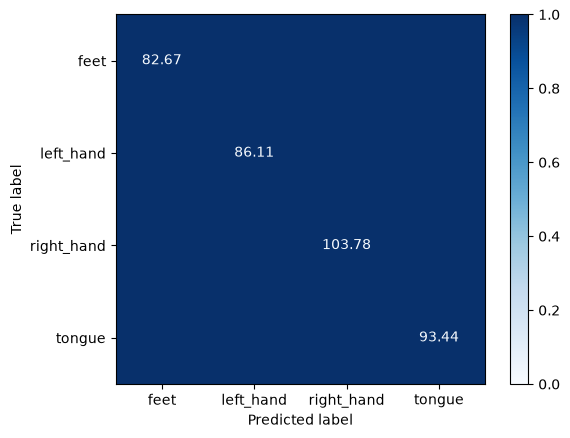



================ SCALE 2.0 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8620153356481483), 'fmeasure': 0.6211610720470954}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6684027777777778, 'auc': np.float64(0.882860725308642), 'fmeasure': 0.6673919465508392}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.8641010802469137), 'fmeasure': 0.62068818616744}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8713509516460906), 'fmeasure': 0.6304592988395082}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6493055555555556, 'auc': np.float64(0.8799832818930041), 'fmeasure': 0.6466761789977075}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8725364904835392), 'fmeasure': 0.6576459461049446}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8688914609053499), 'fmeasure': 0.6110978203083466}

Fold

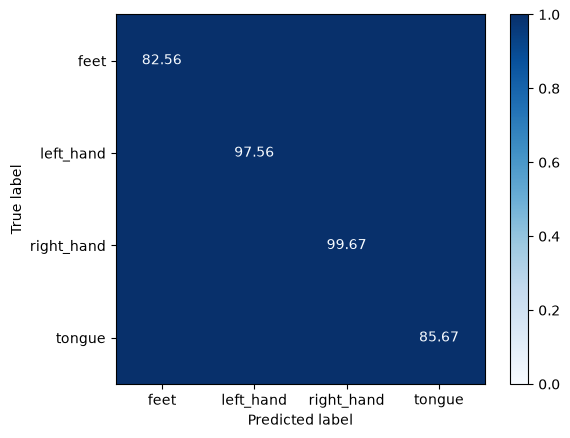



================ SCALE 2.5 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6545138888888888, 'auc': np.float64(0.8701774691358025), 'fmeasure': 0.6510846873676989}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6510416666666666, 'auc': np.float64(0.884841981738683), 'fmeasure': 0.6489114806207001}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8604962384259259), 'fmeasure': 0.6225497416469908}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8722270447530865), 'fmeasure': 0.6307693661352198}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8801199202674898), 'fmeasure': 0.6356099886745686}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8741841885288064), 'fmeasure': 0.6438979240341923}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8656000835905351), 'fmeasure': 0.6389110444517654}

Fold 8/9

Fold 

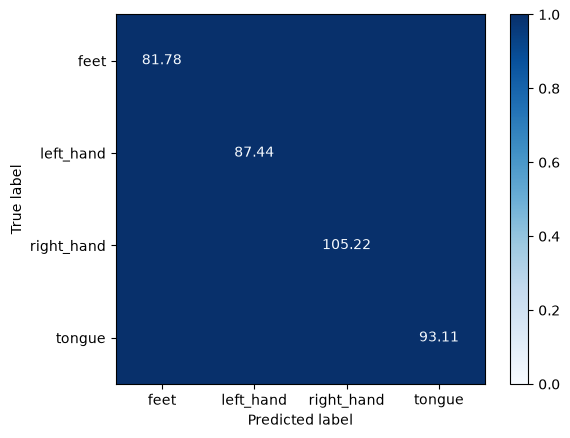

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.5, 1.5, 2.0, 2.5]:

    print(f"\n\n================ SCALE {scale} ================")

    X_scaled = X_cv.copy()

    for idx in range(22):
        X_scaled[:, 0, idx, :] *= scale

    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_scaled[train_idx], X_scaled[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        im_kw={"vmin": 0, "vmax": 1},
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

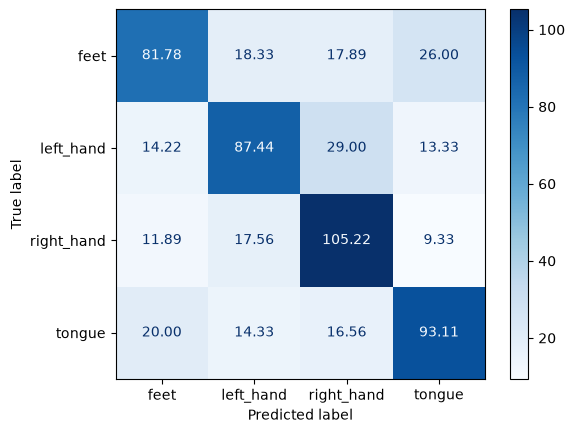

In [37]:
cm1=np.array([
 [ 76.55555556,  24.33333333,  18.77777778,  24.33333333],
 [  9.22222222, 100.11111111,  24.88888889,   9.77777778],
 [ 10.55555556,  27.22222222,  96.55555556,   9.66666667],
 [ 19.33333333,  19.        ,  13.66666667,  92.        ]])

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
)
disp.plot(
        cmap="Blues",
        values_format=".2f"
)

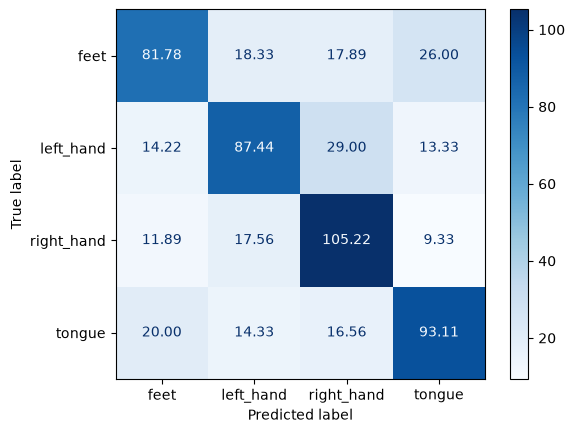

In [38]:
cm2=np.array(
[[ 82.66666667,  14.44444444,  19.66666667,  27.22222222],
 [ 14.11111111,  86.11111111,  32.11111111,  11.66666667],
 [ 13.         ,  16.44444444, 103.77777778,  10.77777778],
 [ 19.11111111,  12.22222222,  19.22222222,  93.44444444]])

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
)
disp.plot(
        cmap="Blues",
        values_format=".2f"
)



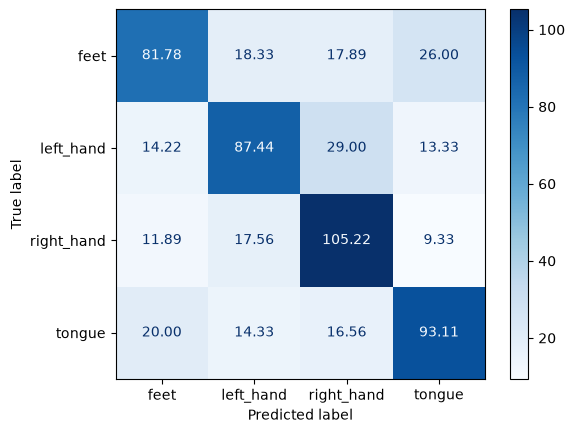

In [39]:
cm3=np.array(
[[82.55555556, 22.33333333, 17.11111111, 22.        ],
 [11.77777778, 97.55555556, 26.11111111,  8.55555556],
 [13.44444444, 24.11111111, 99.66666667,  6.77777778],
 [22.88888889, 19.11111111, 16.33333333, 85.66666667]])

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
)
disp.plot(
        cmap="Blues",
        values_format=".2f"
)



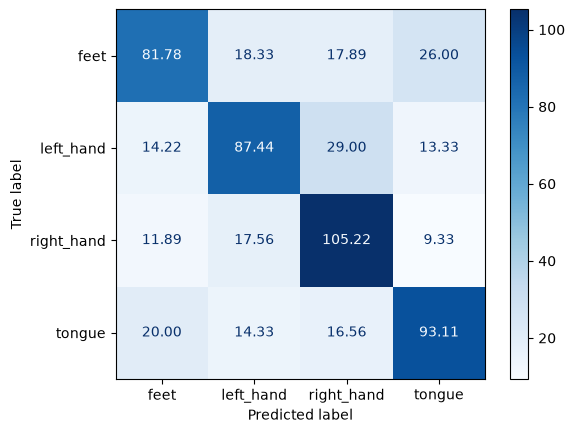

In [40]:
cm4=np.array(
[[ 81.77777778,  18.33333333,  17.88888889,  26.        ],
 [ 14.22222222,  87.44444444,  29.         ,  13.33333333],
 [ 11.88888889,  17.55555556, 105.22222222,   9.33333333],
 [ 20.         ,  14.33333333,  16.55555556,  93.11111111]])

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
)
disp.plot(
        cmap="Blues",
        values_format=".2f"
)



In [41]:
cm=(cm1+cm2+cm3+cm4)/4

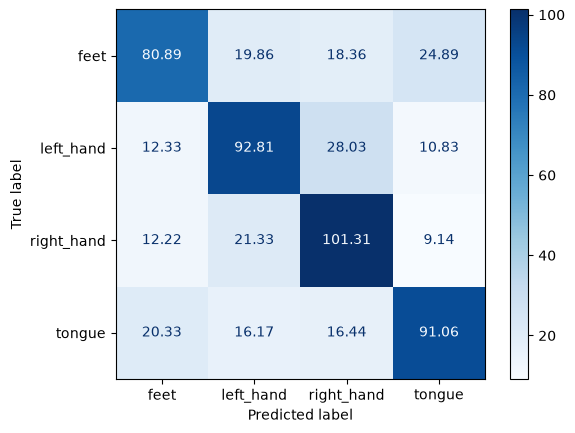

In [43]:

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
)
disp.plot(
        cmap="Blues",
        values_format=".2f"
)



## Train alone



================ SCALE 0.5 ================

Fold 1/9


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(



Fold 1 Final Validation -
{'acc': 0.6631944444444444, 'auc': np.float64(0.8880047582304527), 'fmeasure': 0.6659004261319512}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6649305555555556, 'auc': np.float64(0.889427404835391), 'fmeasure': 0.6680432927909921}

Fold 3/9
Early stopping at epoch 33

Fold 3 Final Validation -
{'acc': 0.5625, 'auc': np.float64(0.8228563850308642), 'fmeasure': 0.5629177265864298}

Fold 4/9
Early stopping at epoch 44

Fold 4 Final Validation -
{'acc': 0.5555555555555556, 'auc': np.float64(0.8502121913580245), 'fmeasure': 0.5576557191158209}

Fold 5/9
Early stopping at epoch 31

Fold 5 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.8408805941358025), 'fmeasure': 0.5906134427608447}

Fold 6/9
Early stopping at epoch 32

Fold 6 Final Validation -
{'acc': 0.5815972222222222, 'auc': np.float64(0.8326621977880658), 'fmeasure': 0.580808498136613}

Fold 7/9
Early stopping at epoch 33

Fold 7 Final Validation -
{'acc': 0.5555555555555556, 'auc': n

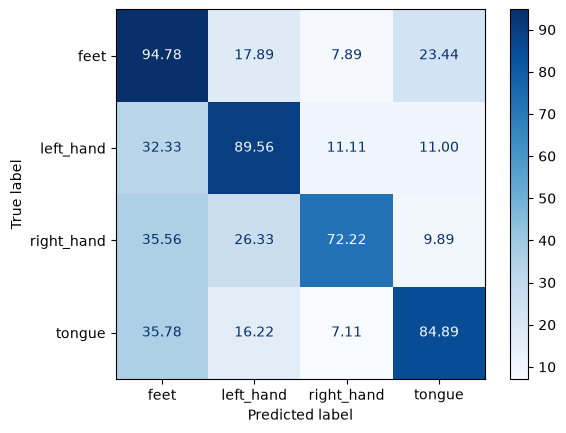



================ SCALE 1.5 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5920138888888888, 'auc': np.float64(0.8506020126028807), 'fmeasure': 0.577269072122115}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8711138438786009), 'fmeasure': 0.6333709763833941}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.8498947080761315), 'fmeasure': 0.5818848568784621}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.5972222222222222, 'auc': np.float64(0.869044174382716), 'fmeasure': 0.5898296936938064}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8684614519032922), 'fmeasure': 0.6333962674324412}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8581934799382717), 'fmeasure': 0.5948361050221327}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.8572209362139919), 'fmeasure': 0.5735043182146874}

Fold 8/9

Fol

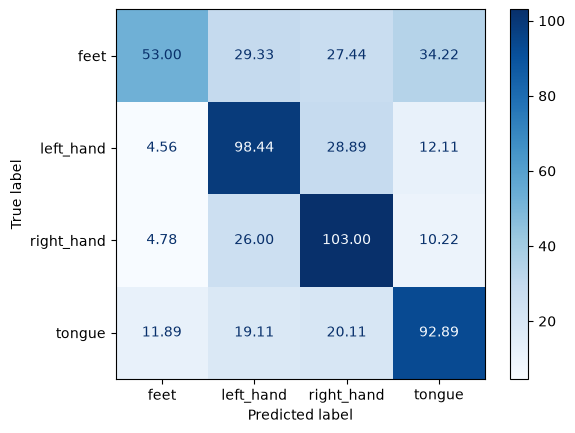



================ SCALE 2.0 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.8475075552983539), 'fmeasure': 0.5808361159697333}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.5451388888888888, 'auc': np.float64(0.8662471064814815), 'fmeasure': 0.49876029472666317}

Fold 3/9
Early stopping at epoch 59

Fold 3 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.851124453446502), 'fmeasure': 0.6043663447670701}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.5520833333333334, 'auc': np.float64(0.8529811278292181), 'fmeasure': 0.5281350860296313}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.5989583333333334, 'auc': np.float64(0.8537125450102881), 'fmeasure': 0.5862225094184781}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5520833333333334, 'auc': np.float64(0.8434084040637858), 'fmeasure': 0.5207988101488502}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5607638888888888, 'auc': np.float64(0.8494928305041153), 'fmeasure': 0.547

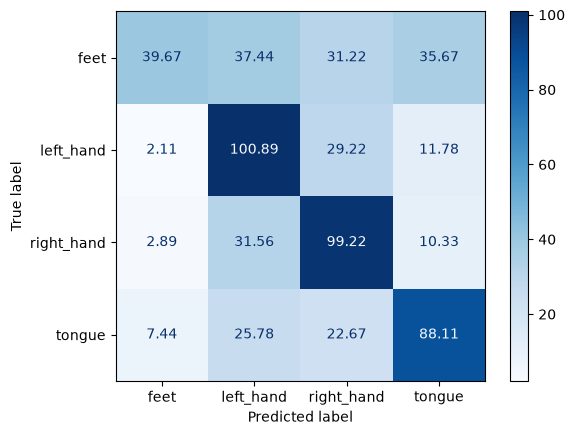



================ SCALE 2.5 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5677083333333334, 'auc': np.float64(0.8478370949074074), 'fmeasure': 0.5423534798534799}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.5295138888888888, 'auc': np.float64(0.8597286522633745), 'fmeasure': 0.5181999237602684}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5104166666666666, 'auc': np.float64(0.8472342785493826), 'fmeasure': 0.47439270173837644}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.5295138888888888, 'auc': np.float64(0.8455785429526749), 'fmeasure': 0.47841496765330743}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.5260416666666666, 'auc': np.float64(0.839795524691358), 'fmeasure': 0.49707884229803195}

Fold 6/9
Early stopping at epoch 48

Fold 6 Final Validation -
{'acc': 0.4670138888888889, 'auc': np.float64(0.8202120306069958), 'fmeasure': 0.4271823045367546}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.4565972222222222, 'auc': np.float64(0.830371495627572), 'fmeas

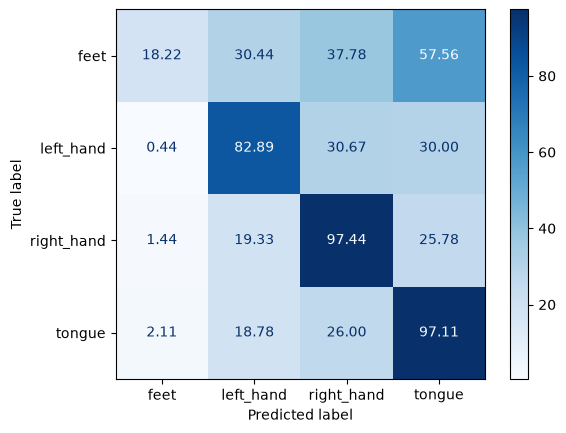

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}
num_epochs = 60
for scale in [0.5, 1.5, 2.0, 2.5]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

        for idx in range(22):
            X_tr[:, 0, idx, :] *= scale

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

## test



================ SCALE 0.5 ================

Fold 1/9


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(



Fold 1 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8463581854423868), 'fmeasure': 0.5950759744624372}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8647320280349794), 'fmeasure': 0.5823274191058578}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5833333333333334, 'auc': np.float64(0.8564292373971195), 'fmeasure': 0.5593280402631986}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.5920138888888888, 'auc': np.float64(0.8626503022119342), 'fmeasure': 0.5696010676859196}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.5677083333333334, 'auc': np.float64(0.8614446694958847), 'fmeasure': 0.5505973050968576}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5277777777777778, 'auc': np.float64(0.8543595679012345), 'fmeasure': 0.5065111014739375}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5347222222222222, 'auc': np.float64(0.8379750192901235), 'fmeasure': 0.4999767720967622}

Fold 8/9

Fold 8 Final Validation -
{'acc': 0.57118055555

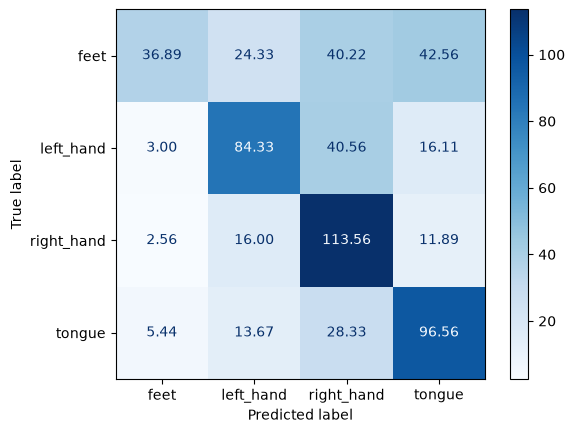



================ SCALE 1.5 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8755947788065844), 'fmeasure': 0.6468241325643138}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6666666666666666, 'auc': np.float64(0.885376478909465), 'fmeasure': 0.6668023544447489}

Fold 3/9
Early stopping at epoch 52

Fold 3 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.8545283564814815), 'fmeasure': 0.6090017374052186}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8752732767489713), 'fmeasure': 0.6146497168456396}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.8697233474794239), 'fmeasure': 0.6298588600541314}

Fold 6/9
Early stopping at epoch 50

Fold 6 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8503809799382717), 'fmeasure': 0.6140063767700769}

Fold 7/9
Early stopping at epoch 52

Fold 7 Final Validation -
{'acc': 0.5833333333333334, 'au

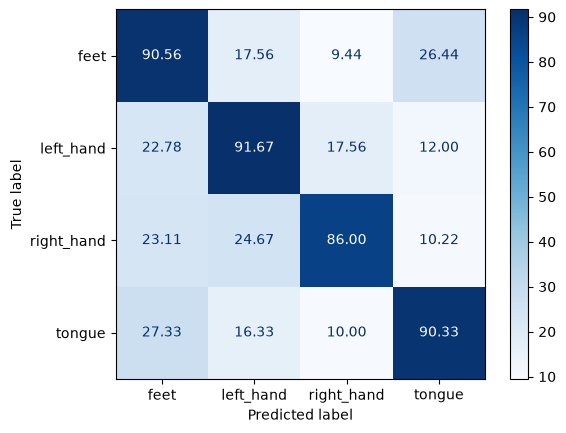



================ SCALE 2.0 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5972222222222222, 'auc': np.float64(0.863574620627572), 'fmeasure': 0.6032374908576851}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8760207690329218), 'fmeasure': 0.6530264675692813}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8534915123456789), 'fmeasure': 0.6079336487517265}

Fold 4/9
Early stopping at epoch 57

Fold 4 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8625900205761315), 'fmeasure': 0.6233876008957411}

Fold 5/9
Early stopping at epoch 46

Fold 5 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.854857896090535), 'fmeasure': 0.5900308941686228}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.868847254372428), 'fmeasure': 0.6208426537988916}

Fold 7/9
Early stopping at epoch 45

Fold 7 Final Validation -
{'acc': 0.5694444444444444, 'auc': n

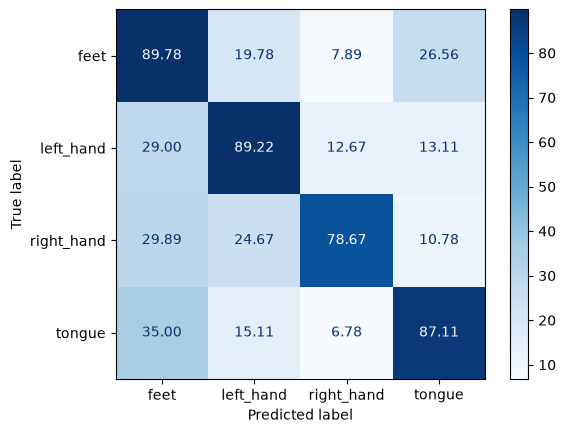



================ SCALE 2.5 ================

Fold 1/9
Early stopping at epoch 15

Fold 1 Final Validation -
{'acc': 0.2586805555555556, 'auc': np.float64(0.5737284593621399), 'fmeasure': 0.14908923273390645}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6597222222222222, 'auc': np.float64(0.8783757716049383), 'fmeasure': 0.6606844694874232}

Fold 3/9
Early stopping at epoch 24

Fold 3 Final Validation -
{'acc': 0.4809027777777778, 'auc': np.float64(0.7772472993827161), 'fmeasure': 0.47090612418285505}

Fold 4/9
Early stopping at epoch 15

Fold 4 Final Validation -
{'acc': 0.2760416666666667, 'auc': np.float64(0.5697096836419754), 'fmeasure': 0.175736269104613}

Fold 5/9
Early stopping at epoch 52

Fold 5 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8571968235596706), 'fmeasure': 0.6169480986759823}

Fold 6/9
Early stopping at epoch 38

Fold 6 Final Validation -
{'acc': 0.5590277777777778, 'auc': np.float64(0.8291096000514404), 'fmeasure': 0.5577696369211015}

F

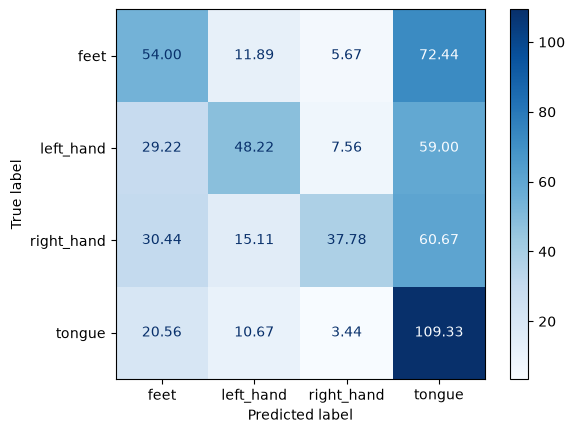

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}
num_epochs = 60
for scale in [0.5, 1.5, 2.0, 2.5]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

        for idx in range(22):
            X_va[:, 0, idx, :] *= scale

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm